In [1]:
from sklearn.datasets import load_iris
iris = load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

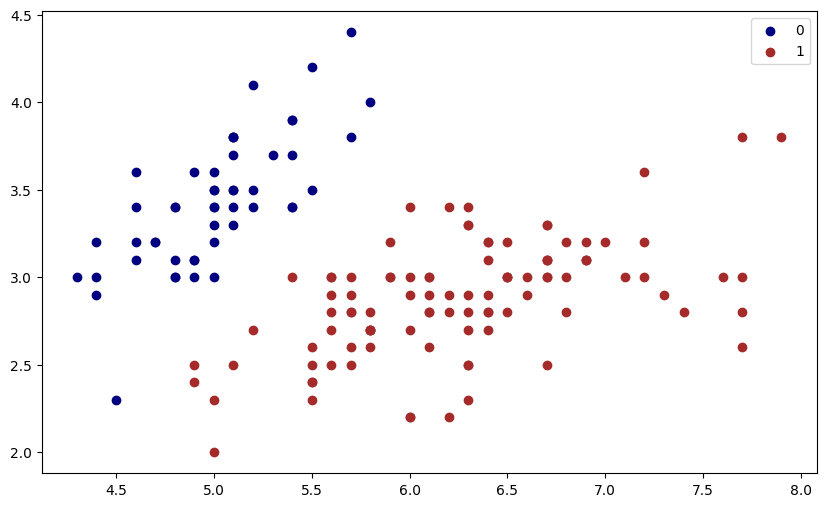

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
# 데이터 플롯도를 작성
iris = datasets.load_iris()

# nbarray의 2차원 배열
X = iris.data[:, :2]
# iris.target은 0(=setosa), 1(=versicolor), 2(=virginica)이 저장되어 있는
# nbarray의 일차원 배열
y= np.where(iris.target!=0, 1, iris.target)
# np.where(조건, 참일 때 값, 거짓일 때 값)
# 결과 : 0은 0으로 1과 2는 1로 변환
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='navy', label='0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='brown', label='1')
plt.legend();

In [6]:
import numpy as np
from sklearn.datasets import load_iris

def add_intercept(X):
    # 다중 선형 회귀를 계산하기 위한 행렬을 작성
    intercept = np.ones((X.shape[0], 1))
    return np.concatenate((intercept,X),axis=1)
def sigmoid(z):
    # 시그모이드 함수
    return 1 / (1 + np.exp(-z))
def cross_entropy(h, y):
    # 교차 엔트로피 오차
    return (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()
def predict_prob(X, theta):
    # 교차 엔트로피 오차가 가장 작은 최신의 가중치를 이용하여 X의 데이터로부터 확률의 예측값을 출력

    X = add_intercept(X)
    return sigmoid(np.dot(X,theta))
def predict(X, theta):
    #  시그모이드 함수에 의해 출력된 확률의 예측값에서 0.5 이상은 1, 0.5이하는 0으로 분류한 라벨을 출력
    return predict_prob(X,theta).round()

In [11]:
# 학습률을 찾는다
lr = 0.1
iter_nums = 300000

X = add_intercept(X)

# 가중치의 초기화
theta = np.zeros(X.shape[1])

# 최급강하법
for i in range(iter_nums):
    z = np.dot(X, theta)
    h = sigmoid(z)

    # 기울기(=편미분항)을 계산
    gradient = np.dot(X.T, (h -y)) / y.size

    # 가중치를 갱신
    theta = theta - lr * gradient

    # 교차 엔트로피 오차를 지정
    loss = cross_entropy(h, y)
    if(i % 10000 == 0 ):
        # 교차 엔트로피 오차를 출력
        print(f'loss: {loss} \t')


# 확율값 예측
iris = load_iris()
X = iris.data[:,:2]
predict_prob(X, theta)
# 확률값을 사용하여 분류 라벨을 예측
predict(X, theta)

loss: 0.6931471805599454 	
loss: 0.03432808634642343 	
loss: 0.028787025832133467 	
loss: 0.02571880776427713 	
loss: 0.023408635212947112 	
loss: 0.021507199017176955 	
loss: 0.019892517590830612 	
loss: 0.018503295528766946 	
loss: 0.017299305807070196 	
loss: 0.01624983679491448 	
loss: 0.015329924723359766 	
loss: 0.01451890984433595 	
loss: 0.013799672865938828 	
loss: 0.013158067641994306 	
loss: 0.012582429565328927 	
loss: 0.012063141842400473 	
loss: 0.011592261833140768 	
loss: 0.011163207785515772 	
loss: 0.010770501660660363 	
loss: 0.010409560916002604 	
loss: 0.01007653127087266 	
loss: 0.009768152873869885 	
loss: 0.009481653254137872 	
loss: 0.009214661554388425 	
loss: 0.008965139601333912 	
loss: 0.008731326283947356 	
loss: 0.008511692462681702 	
loss: 0.0083049042347413 	
loss: 0.008109792854048281 	
loss: 0.00792532997370261 	


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

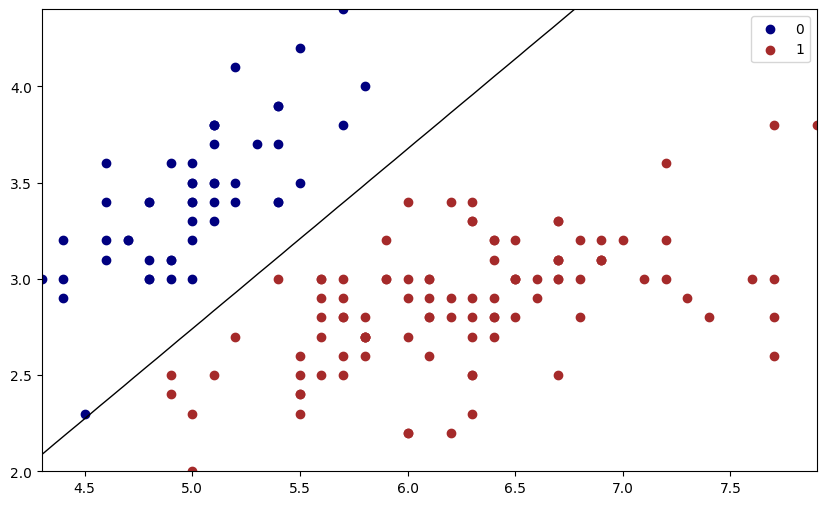

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터를 플롯
plt.figure(figsize=(10,6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='navy', label='0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='brown', label='1')
plt.legend()

# x축의 스케일 폭을 정의
x_min, x_max = X[:,0].min(), X[:,0].max()
# y축의 스케일 폭을 정의
y_min, y_max = X[:,1].min(), X[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max), np.linspace(y_min, y_max))
grid = np.c_[xx.ravel(), yy.ravel()]
# 분류한 선을 표시
probs = predict_prob(grid, theta).reshape(xx.shape)
plt.contour(xx, yy,probs, [0.5], linewidths=1, colors='black');

In [15]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
iris = load_iris()
X = iris.data[:, :2]
y=np.where(iris.target!=0, 1, iris.target)
model = LogisticRegression()
model.fit(X, y)
model.predict(X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])